In [ ]:
#---------------------------------------------------------------------------------------------
# EXTRACTION DES DONNEES
#---------------------------------------------------------------------------------------------

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon Dec  7 17:44:34 2020

@author: delyon
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import pandas

# Adresse des deux fichiers de donnees
# https://perso.univ-rennes1.fr/bernard.delyon/tp/Vent.csv
# https://perso.univ-rennes1.fr/bernard.delyon/tp/Vagues.csv

etudiant = 14003508
 # nombre à remplacer par votre numéro d'etudiant
np.random.seed(etudiant)

# Lecture des donnees
nomvar=np.loadtxt("Vent.csv",delimiter=',',dtype='str',max_rows=1)[1:]
X=np.loadtxt("Vent.csv",delimiter=',',skiprows=1,usecols=1+np.arange(len(nomvar)))
y=np.loadtxt("Vagues.csv",delimiter=',',skiprows=1,usecols=1)
n=len(y)

# On extrait un sous-ensemble d'individus
select=np.random.choice(n,size=n//8, replace=False)
X=X[select,:]
y=y[select]
n=n=len(y)

X = X**2 #linearisation

=== Variable cible : hauteur des vagues (y) ===
  n=1000, min=0.40, max=7.21, moy=1.94, std=1.21


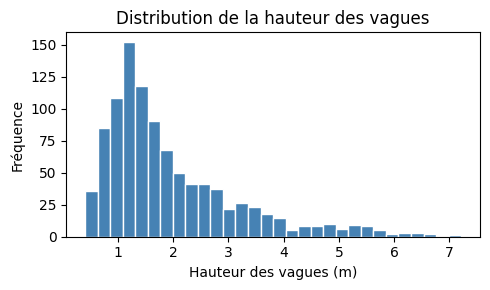

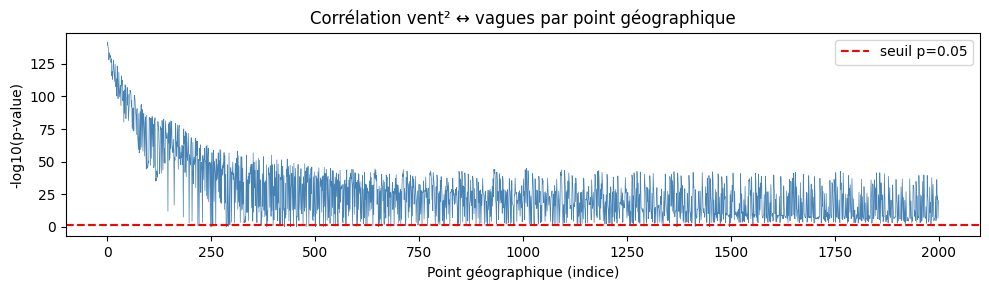

Variables significatives (p<0.05) : 1959 / 2000


In [ ]:
#---------------------------------------------------------------------------------------------
# ANALYSE EXPLORATOIRE
#---------------------------------------------------------------------------------------------

# --- Statistiques descriptives ---
print("=== Variable cible : hauteur des vagues (y) ===")
print(f"  n={len(y)}, min={y.min():.2f}, max={y.max():.2f}, moy={y.mean():.2f}, std={y.std():.2f}")

# --- Histogramme de y ---
plt.figure(figsize=(5, 3))
plt.hist(y, bins=30, color='steelblue', edgecolor='white')
plt.xlabel("Hauteur des vagues (m)")
plt.ylabel("Fréquence")
plt.title("Distribution de la hauteur des vagues")
plt.tight_layout()
plt.show()

# --- Corrélations vent²→vagues (sur tout X avant split) ---
from sklearn.feature_selection import f_regression
X_sq = X  # déjà au carré
F_scores, p_values = f_regression(X_sq, y)

plt.figure(figsize=(10, 3))
plt.plot(-np.log10(p_values), color='steelblue', linewidth=0.5)
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='seuil p=0.05')
plt.xlabel("Point géographique (indice)")
plt.ylabel("-log10(p-value)")
plt.title("Corrélation vent² ↔ vagues par point géographique")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Variables significatives (p<0.05) : {(p_values < 0.05).sum()} / {len(p_values)}")

In [ ]:
#---------------------------------------------------------------------------------------------
# PREPARATION DES DONNEES
#---------------------------------------------------------------------------------------------

# decoupage : 80% des donnes pour l'echantillon d'apprentissage et 20% pour l'echantillon de test
ntest = int(n * 0.2)
per = np.random.permutation(n)
lt, la = per[:ntest], per[ntest:]
X_app, y_app = X[la, :], y[la]
X_test, y_test = X[lt, :], y[lt]

# Standardisation
moyenne_X = np.mean(X_app, axis=0)
ecart_type_X = np.std(X_app, axis=0)
X_app = (X_app - moyenne_X) / ecart_type_X
X_test = (X_test - moyenne_X) / ecart_type_X



------------------ SANS SELECTION DES VARIABLES ------------------

--- OLS avec Scikit-Learn ---
MSE OLS Apprentissage =  0.0
RMSE OLS Apprentissage =  0.0
MSE OLS Test =  1.95
RMSE OLS Test =  1.4


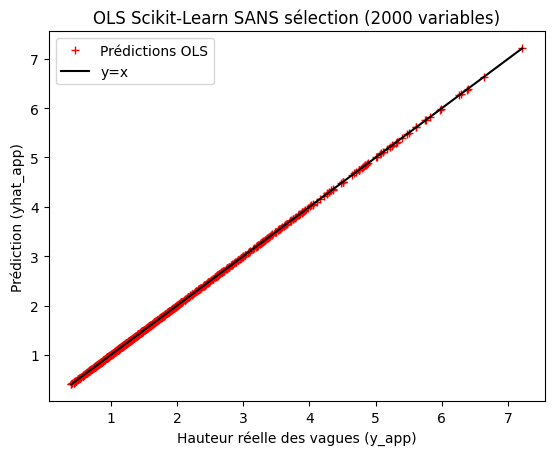

In [ ]:
print("\n------------------ SANS SELECTION DES VARIABLES ------------------")

#---------------------------------------------------------------------------------------------
# MODÈLE OLS AVEC SCIKIT-LEARN
#---------------------------------------------------------------------------------------------

print("\n--- OLS avec Scikit-Learn ---")

reg = LinearRegression()
reg.fit(X_app, y_app)
yhat_app = reg.predict(X_app)

# MSE echentillon apprentissage
MSE_app = sum((yhat_app - y_app)**2) / len(y_app)
print('MSE OLS Apprentissage = ', MSE_app.round(2))
print('RMSE OLS Apprentissage = ', np.sqrt(MSE_app).round(2))

# MSE echantillon test
yhat_test = reg.predict(X_test)
MSE_test = sum((yhat_test - y_test)**2) / len(y_test)
print('MSE OLS Test = ', MSE_test.round(2))
print('RMSE OLS Test = ', np.sqrt(MSE_test).round(2))

plt.figure()
plt.plot(y_app, yhat_app, 'r+', label='Prédictions OLS')
plt.plot([min(y_app), max(y_app)], [min(y_app), max(y_app)], color='black', label='y=x')
plt.xlabel('Hauteur réelle des vagues (y_app)')
plt.ylabel('Prédiction (yhat_app)')
plt.title('OLS Scikit-Learn SANS sélection (2000 variables)')
plt.legend()
plt.show()


In [ ]:
#---------------------------------------------------------------------------------------------
# VALIDATION CROISEE
#---------------------------------------------------------------------------------------------
# LOO

MSELOO = 0
n_app = len(y_app)

for i in range(n_app):
    Xa, Xt = np.delete(X_app, i, axis=0), X_app[[i], :]
    ya, yt = np.delete(y_app, i), y_app[i]
    reg.fit(X=Xa, y=ya)
    yhat = reg.predict(Xt)

    MSELOO += (yt - yhat)**2

print('RMSE LOO = ', np.sqrt(MSELOO / n_app))


#K-Fold
MSECV = 0
it = 30
ntest = n_app // 5

for i in range(it):
    per = np.random.permutation(X_app.shape[0])
    lt, la = per[:ntest], per[ntest:]
    Xa, Xt = X_app[la, :], X_app[lt, :]
    ya, yt = y_app[la], y_app[lt]
    reg.fit(X=Xa, y=ya)
    yhat = reg.predict(Xt)

    MSECV += sum((yt - yhat)**2)

print('RMSE CV 1/5 = ', np.sqrt(MSECV / (it * ntest)))

RMSE LOO =  [1.43824454]
RMSE CV 1/5 =  1.4261190095511875



------------------ AVEC SELECTION DES VARIABLES ------------------
Nouvelle dimension de X_app : (800, 500)

--- OLS avec Scikit-Learn ---
MSE OLS Apprentissage =  0.13
RMSE OLS Apprentissage =  0.36
MSE OLS Test =  1.4
RMSE OLS Test =  1.18


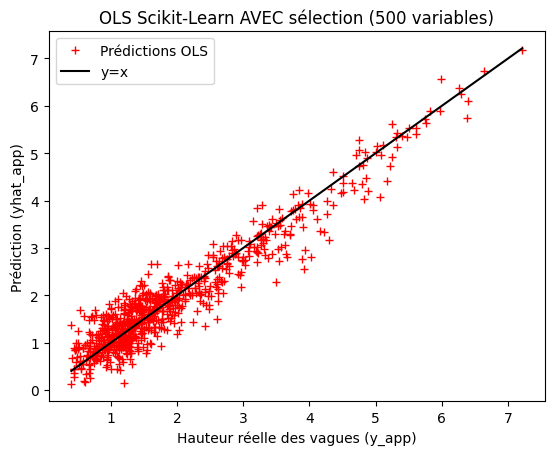

RMSE LOO =  [1.56867912]
RMSE CV 1/5 =  2.092330256561097


In [ ]:
#---------------------------------------------------------------------------------------------
# SELECTION DES VARIABLES & TESTS AVEC LA SELECTION
#---------------------------------------------------------------------------------------------

print("\n------------------ AVEC SELECTION DES VARIABLES ------------------")

#selection des variables avec la p-value la plus petite pour temps de calculs
from sklearn.feature_selection import f_regression, SelectKBest
selector = SelectKBest(f_regression, k=500)
X_app_reduit = selector.fit_transform(X_app, y_app)
X_test_reduit = selector.transform(X_test)
#affichage
scores = selector.pvalues_
print(f"Nouvelle dimension de X_app : {X_app_reduit.shape}")

#---------------------------------------------------------------------------------------------
# MODÈLE OLS MANUEL
#---------------------------------------------------------------------------------------------
# print("\n--- OLS manuel ---")

# X1 = np.append(np.ones((len(y_app), 1)), X_app_reduit, axis=1)
# Xt = X1.T
# Ri = np.linalg.inv(Xt.dot(X1))
# bet = Ri.dot((Xt).dot(y_app))
# yhat_manuel = X1.dot(bet)

# print("Coefficients manuels (Constante + 5 premiers variables) :")
# print(*np.around(bet[:6], 3))

# plt.figure()
# plt.plot(y_app, yhat_manuel, 'r+', label='Prédictions manuelles')
# plt.xlabel('Hauteur réelle des vagues (y_app)')
# plt.ylabel('Prédiction (yhat_manuel)')
# plt.plot([min(y_app), max(y_app)], [min(y_app), max(y_app)], color='black', label='y=x')
# plt.title('Droite de regression (Formule manuelle)')
# plt.legend()
# plt.show()

#---------------------------------------------------------------------------------------------
# MODÈLE OLS AVEC SCIKIT-LEARN
#---------------------------------------------------------------------------------------------

print("\n--- OLS avec Scikit-Learn ---")

reg = LinearRegression()
reg.fit(X_app_reduit, y_app)
yhat_app = reg.predict(X_app_reduit)

# MSE echentillon apprentissage
MSE_app = sum((yhat_app - y_app)**2) / len(y_app)
print('MSE OLS Apprentissage = ', MSE_app.round(2))
print('RMSE OLS Apprentissage = ', np.sqrt(MSE_app).round(2))

# MSE echantillon test
yhat_test = reg.predict(X_test_reduit)
MSE_test = sum((yhat_test - y_test)**2) / len(y_test)
print('MSE OLS Test = ', MSE_test.round(2))
print('RMSE OLS Test = ', np.sqrt(MSE_test).round(2))

plt.figure()
plt.plot(y_app, yhat_app, 'r+', label='Prédictions OLS')
plt.plot([min(y_app), max(y_app)], [min(y_app), max(y_app)], color='black', label='y=x')
plt.xlabel('Hauteur réelle des vagues (y_app)')
plt.ylabel('Prédiction (yhat_app)')
plt.title('OLS Scikit-Learn AVEC sélection (500 variables)')
plt.legend()
plt.show()

#---------------------------------------------------------------------------------------------
# VALIDATION CROISEE
#---------------------------------------------------------------------------------------------
# LOO

MSELOO = 0
n_app = len(y_app)

for i in range(n_app):
    Xa, Xt = np.delete(X_app_reduit, i, axis=0), X_app_reduit[[i], :]
    ya, yt = np.delete(y_app, i), y_app[i]
    reg.fit(X=Xa, y=ya)
    yhat = reg.predict(Xt)

    MSELOO += (yt - yhat)**2

print('RMSE LOO = ', np.sqrt(MSELOO / n_app))


#K-Fold
MSECV = 0
it = 30
ntest = n_app // 5

for i in range(it):
    per = np.random.permutation(X_app_reduit.shape[0])
    lt, la = per[:ntest], per[ntest:]
    Xa, Xt = X_app_reduit[la, :], X_app_reduit[lt, :]
    ya, yt = y_app[la], y_app[lt]
    reg.fit(X=Xa, y=ya)
    yhat = reg.predict(Xt)

    MSECV += sum((yt - yhat)**2)

print('RMSE CV 1/5 = ', np.sqrt(MSECV / (it * ntest)))



--- Ridge ---
RMSE Ridge CV (alpha=10) = 0.88
RMSE Ridge CV (alpha=100) = 0.78
RMSE Ridge CV (alpha=500) = 0.75
RMSE Ridge CV (alpha=1000) = 0.74
RMSE Ridge CV (alpha=5000) = 0.75
RMSE Ridge Test final = 0.74


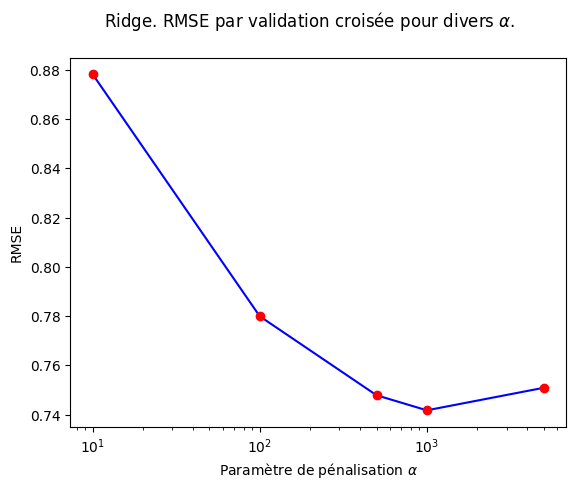

In [ ]:
#---------------------------------------------------------------------------------------------
# RIDGE
#---------------------------------------------------------------------------------------------

print("\n--- Ridge ---")

B = 30
ntest_cv = len(y_app) // 5
alphas_ridge = [10, 100, 500, 1000, 5000]
mse_ridge = np.zeros(len(alphas_ridge))

for b in range(B):
    per = np.random.permutation(X_app.shape[0])
    lt, la = per[:ntest_cv], per[ntest_cv:]
    Xa, ya = X_app[la, :], y_app[la]
    Xt, yt = X_app[lt, :], y_app[lt]

    for j, a in enumerate(alphas_ridge):
        reg_ridge = Ridge(alpha=a)
        reg_ridge.fit(Xa, ya)
        yh = reg_ridge.predict(Xt)
        mse_ridge[j] += np.mean((yh - yt)**2)

mse_ridge = mse_ridge / B
rmse_ridge = np.sqrt(mse_ridge)

for j, a in enumerate(alphas_ridge):
    print(f"RMSE Ridge CV (alpha={a}) = {rmse_ridge[j].round(2)}")

best_alpha_ridge = alphas_ridge[np.argmin(rmse_ridge)]
mod_ridge_final = Ridge(alpha=best_alpha_ridge)
mod_ridge_final.fit(X_app, y_app)
yhat_ridge_test = mod_ridge_final.predict(X_test)
print('RMSE Ridge Test final =', np.sqrt(np.mean((yhat_ridge_test - y_test)**2)).round(2))

plt.figure()
plt.suptitle(r'Ridge. RMSE par validation croisée pour divers $\alpha$.')
plt.semilogx()
plt.plot(alphas_ridge, rmse_ridge, 'b-', alphas_ridge, rmse_ridge, 'ro')
plt.xlabel(r'Paramètre de pénalisation $\alpha$')
plt.ylabel('RMSE')
plt.show()


--- Lasso ---
RMSE Lasso CV (alpha=0.01) = 0.74
RMSE Lasso CV (alpha=0.1) = 0.75
RMSE Lasso CV (alpha=1) = 1.23
RMSE Lasso CV (alpha=10) = 1.23
RMSE Lasso Test final = 0.72
Variables non nulles : 109 / 2000


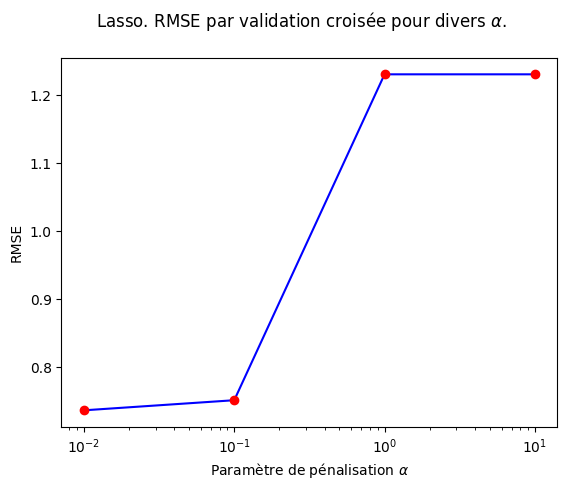

In [ ]:
#---------------------------------------------------------------------------------------------
# LASSO
#---------------------------------------------------------------------------------------------

print("\n--- Lasso ---")

B = 30
ntest_cv = len(y_app) // 5
alphas_lasso = [0.01, 0.1, 1, 10]
mse_lasso = np.zeros(len(alphas_lasso))

for b in range(B):
    per = np.random.permutation(X_app.shape[0])
    lt, la = per[:ntest_cv], per[ntest_cv:]
    Xa, ya = X_app[la, :], y_app[la]
    Xt, yt = X_app[lt, :], y_app[lt]

    for j, a in enumerate(alphas_lasso):
        reg_lasso = Lasso(alpha=a, max_iter=10000)
        reg_lasso.fit(Xa, ya)
        yh = reg_lasso.predict(Xt)
        mse_lasso[j] += np.mean((yh - yt)**2)

mse_lasso = mse_lasso / B
rmse_lasso = np.sqrt(mse_lasso)

for j, a in enumerate(alphas_lasso):
    print(f"RMSE Lasso CV (alpha={a}) = {rmse_lasso[j].round(2)}")

best_alpha_lasso = alphas_lasso[np.argmin(rmse_lasso)]
mod_lasso_final = Lasso(alpha=best_alpha_lasso, max_iter=10000)
mod_lasso_final.fit(X_app, y_app)
yhat_lasso_test = mod_lasso_final.predict(X_test)
print('RMSE Lasso Test final =', np.sqrt(np.mean((yhat_lasso_test - y_test)**2)).round(2))
print(f"Variables non nulles : {np.sum(mod_lasso_final.coef_ != 0)} / {X_app.shape[1]}")

plt.figure()
plt.suptitle(r'Lasso. RMSE par validation croisée pour divers $\alpha$.')
plt.semilogx()
plt.plot(alphas_lasso, rmse_lasso, 'b-', alphas_lasso, rmse_lasso, 'ro')
plt.xlabel(r'Paramètre de pénalisation $\alpha$')
plt.ylabel('RMSE')
plt.show()

In [ ]:

#---------------------------------------------------------------------------------------------
# KNN
#---------------------------------------------------------------------------------------------

from sklearn.neighbors import KNeighborsRegressor

print("\n--- KNN ---")

B = 30
ntest_cv = len(y_app) // 5

k_values = [1, 3, 5, 10, 20, 50, 100]
mse_knn = np.zeros(len(k_values))

for b in range(B):
    per = np.random.permutation(X_app.shape[0])
    lt, la = per[:ntest_cv], per[ntest_cv:]
    Xa, ya = X_app[la, :], y_app[la]
    Xt, yt = X_app[lt, :], y_app[lt]

    for j, k in enumerate(k_values):
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(Xa, ya)
        yh = knn.predict(Xt)
        mse_knn[j] += np.mean((yh - yt)**2)

mse_knn = mse_knn / B
rmse_knn = np.sqrt(mse_knn)

for j, k in enumerate(k_values):
    print(f"RMSE KNN CV (k={k}) = {rmse_knn[j].round(2)}")


--- KNN ---
RMSE KNN CV (k=1) = 0.88
RMSE KNN CV (k=3) = 0.83
RMSE KNN CV (k=5) = 0.85
RMSE KNN CV (k=10) = 0.88
RMSE KNN CV (k=20) = 0.91
RMSE KNN CV (k=50) = 0.97
RMSE KNN CV (k=100) = 1.02


In [ ]:
best_k = k_values[np.argmin(rmse_knn)]
print("Meilleur k =", best_k)

Meilleur k = 3


In [ ]:
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_app, y_app)

yhat_knn_test = knn_final.predict(X_test)

print('RMSE KNN Test final =', np.sqrt(np.mean((yhat_knn_test - y_test)**2)).round(2))

RMSE KNN Test final = 0.73


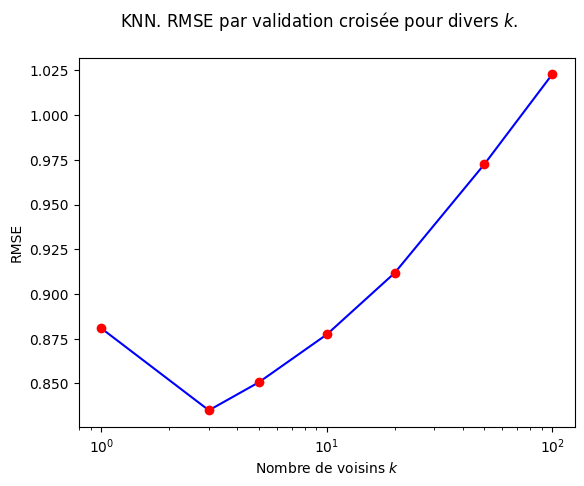

In [ ]:
plt.figure()
plt.suptitle(r'KNN. RMSE par validation croisée pour divers $k$.')
plt.plot(k_values, rmse_knn, 'b-', k_values, rmse_knn, 'ro')
plt.xlabel(r'Nombre de voisins $k$')
plt.ylabel('RMSE')
plt.xscale('log')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
knn_final = KNeighborsRegressor(n_neighbors=3)
knn_final.fit(X_app, y_app)
yhat_knn_final = knn_final.predict(X_test)

models = {
    'Ridge': yhat_ridge_test,
    'Lasso': yhat_lasso_test,
    'KNN':   yhat_knn_final
}

for name, yhat in models.items():
    rmse = np.sqrt(np.mean((yhat - y_test)**2))
    mae  = mean_absolute_error(y_test, yhat)
    r2   = r2_score(y_test, yhat)
    print(f"{name} | RMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.2f}")

Ridge | RMSE=0.74 | MAE=0.58 | R²=0.65
Lasso | RMSE=0.72 | MAE=0.56 | R²=0.67
KNN | RMSE=0.73 | MAE=0.51 | R²=0.66
